In [1]:
import scanpy as sc
import scvi 
import torch
from scvi.external import CellAssign
import pandas as pd
import numpy as np
import scipy
from scipy import sparse
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, sys


In [3]:

d4_dz_clustered = sc.read_h5ad(ANALYSIS_DIR / "clustered_egfDuod_D4_DZ.h5ad")

In [4]:
d4_dz_clustered

## Our 'layers' contains raw 'counts'

AnnData object with n_obs × n_vars = 44381 × 27342
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

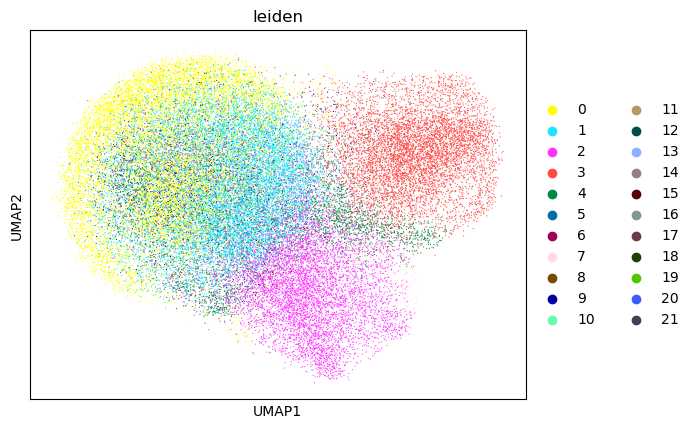

In [5]:
sc.pl.umap(d4_dz_clustered, color="leiden", palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
save="_umap_d4_clustered.pdf")


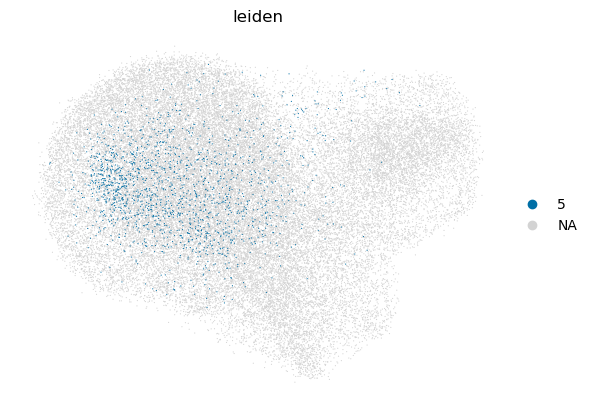

In [6]:
sc.pl.umap(
    d4_dz_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["5"],
    frameon=False
)

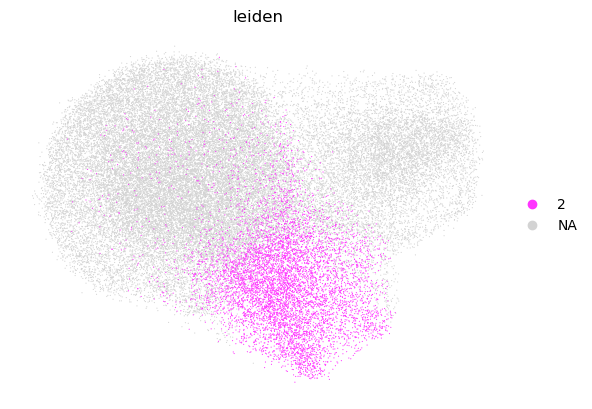

In [7]:
sc.pl.umap(
    d4_dz_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["2"],
    frameon=False
)

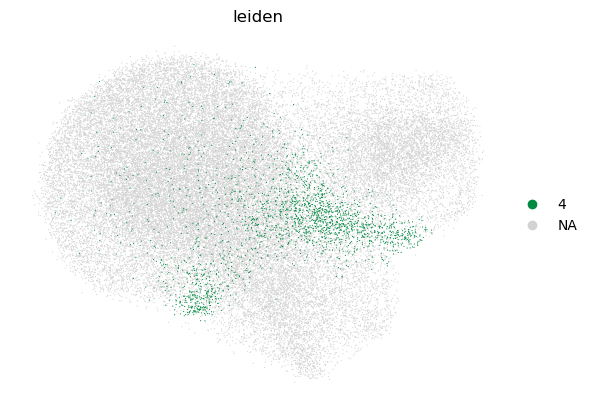

In [8]:
sc.pl.umap(
    d4_dz_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["4"],
    frameon=False
)

In [9]:
def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

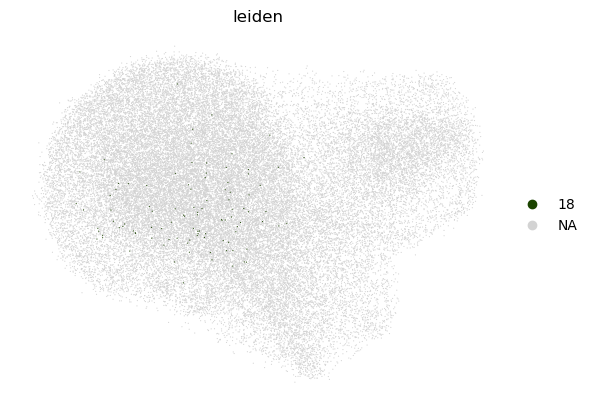

In [10]:
sc.pl.umap(
    d4_dz_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["18"],
    frameon=False
)

In [11]:
# Make sure leiden is string
d4_dz_clustered.obs["leiden"] = d4_dz_clustered.obs["leiden"].astype(str)

# Start with everything as PCs
d4_dz_clustered.obs["manual_label"] = "PCs"

# ISCs: cluster 0
mask_isc = d4_dz_clustered.obs["leiden"] == "0"
d4_dz_clustered.obs.loc[mask_isc, "manual_label"] = "ISCs"

# Enterocytes: cluster 2
mask_ent = d4_dz_clustered.obs["leiden"] == "2"
d4_dz_clustered.obs.loc[mask_ent, "manual_label"] = "Enterocytes"

# Inflammed Secretory PCs: cluster 4 AND REG3A/REG1B/REG1A+
reg3a_pos = gene_expr_bool(d4_dz_clustered, "REG3A")
reg1b_pos = gene_expr_bool(d4_dz_clustered, "REG1B")
reg1a_pos = gene_expr_bool(d4_dz_clustered, "REG1A")

mask_cluster4 = d4_dz_clustered.obs["leiden"] == "4"
mask_inflammed = mask_cluster4 & (reg3a_pos | reg1b_pos | reg1a_pos)
d4_dz_clustered.obs.loc[mask_inflammed, "manual_label"] = "Inflammed Secretory PCs"

# Proliferating PCs: cluster 3 AND MKI67+
mki67_pos = gene_expr_bool(d4_dz_clustered, "MKI67")
mask_cluster3 = d4_dz_clustered.obs["leiden"] == "3"
mask_prolif_pcs = mask_cluster3 & mki67_pos
d4_dz_clustered.obs.loc[mask_prolif_pcs, "manual_label"] = "Proliferating PCs"

# Quick sanity check
print(d4_dz_clustered.obs["manual_label"].value_counts())

manual_label
PCs                        23444
ISCs                       11891
Enterocytes                 7104
Proliferating PCs           1714
Inflammed Secretory PCs      228
Name: count, dtype: int64


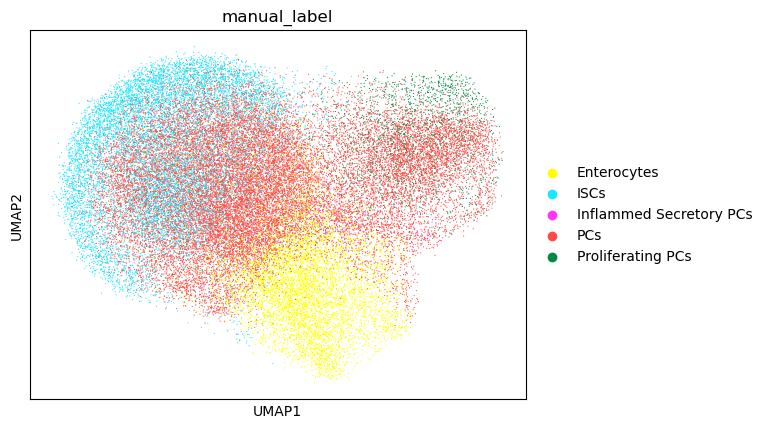

In [12]:
sc.pl.umap(d4_dz_clustered, color = 'manual_label', palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
)

In [13]:
d4_dz_clustered.uns["manual_label_colors"]

['#ffff00', '#1ce6ff', '#ff34ff', '#ff4a46', '#008941']

In [14]:
key = "manual_label"
cats = d4_dz_clustered.obs[key].cat.categories
cols = d4_dz_clustered.uns[f"{key}_colors"]

for c, col in zip(cats, cols):
    print(f"{c}: {col}")


Enterocytes: #ffff00
ISCs: #1ce6ff
Inflammed Secretory PCs: #ff34ff
PCs: #ff4a46
Proliferating PCs: #008941


In [15]:
sc.write(str(ANALYSIS_DIR / "manual_labelled/d4_dz_manual_labels.h5ad"), d4_dz_clustered)